In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conectar a la BD
conn = sqlite3.connect("proyecto_bic.db")

# Cargar datos necesarios para gráficos
df_radiologia = pd.read_sql_query("SELECT * FROM RADIOLOGIA;", conn)
df_pacientes = pd.read_sql_query("SELECT * FROM PACIENTES;", conn)

# Gráfico 1: Diagnóstico vs Tamaño del tumor
# Gráfico 2: Distribución de BI-RADS
# Gráfico 3: Mutaciones más frecuentes

conn.close()

In [2]:
# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Conectar a la base de datos
conn = sqlite3.connect("proyecto_bic.db")

print("✅ Conexión exitosa a la base de datos")

✅ Conexión exitosa a la base de datos


Gráfico 1: Diagnóstico vs Tamaño del tumor (radius)

C:\Users\yerodri\AppData\Local\Temp\ipykernel_27640\1577297112.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tumor, x='diagnostic', y='radius', ax=ax1, palette=['green', 'red'])
C:\Users\yerodri\AppData\Local\Temp\ipykernel_27640\1577297112.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tumor, x='diagnostic', y='area', ax=ax2, palette=['green', 'red'])


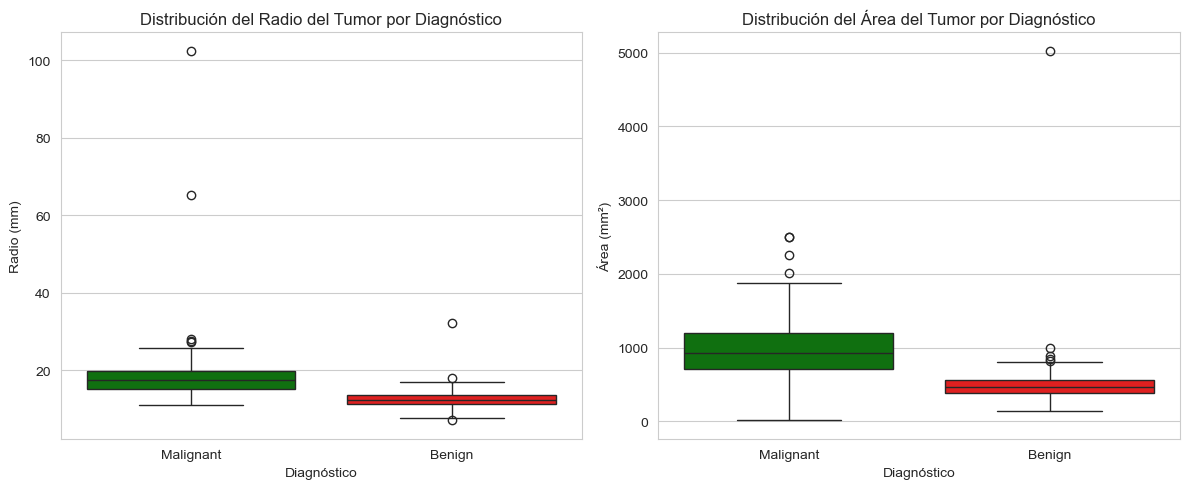


--- Estadísticas resumen ---
           radius                                                        \
            count       mean       std     min     25%     50%      75%   
diagnostic                                                                
Benign      359.0  12.221290  2.055953   6.981  11.130  12.210  13.4250   
Malignant   214.0  18.096542  7.366927  10.950  15.105  17.385  19.6575   

                     area                                                 \
               max  count        mean         std    min     25%     50%   
diagnostic                                                                 
Benign       32.06  359.0  477.220613  275.075321  143.5  379.35  461.00   
Malignant   102.40  214.0  973.738318  371.393193   11.3  706.85  930.15   

                             
                75%     max  
diagnostic                   
Benign       552.95  5021.0  
Malignant   1200.75  2501.0  


In [3]:
# Cargar datos
query1 = '''
SELECT diagnostic, radius, area
FROM RADIOLOGIA
WHERE diagnostic IS NOT NULL
'''

df_tumor = pd.read_sql_query(query1, conn)

# Crear gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de radius por diagnóstico
sns.boxplot(data=df_tumor, x='diagnostic', y='radius', ax=ax1, palette=['green', 'red'])
ax1.set_title('Distribución del Radio del Tumor por Diagnóstico')
ax1.set_xlabel('Diagnóstico')
ax1.set_ylabel('Radio (mm)')

# Boxplot de area por diagnóstico
sns.boxplot(data=df_tumor, x='diagnostic', y='area', ax=ax2, palette=['green', 'red'])
ax2.set_title('Distribución del Área del Tumor por Diagnóstico')
ax2.set_xlabel('Diagnóstico')
ax2.set_ylabel('Área (mm²)')

plt.tight_layout()
plt.show()

# Estadísticas resumen
print("\n--- Estadísticas resumen ---")
print(df_tumor.groupby('diagnostic')[['radius', 'area']].describe())

 Gráfico 2: Distribución de BI-RADS por diagnóstico

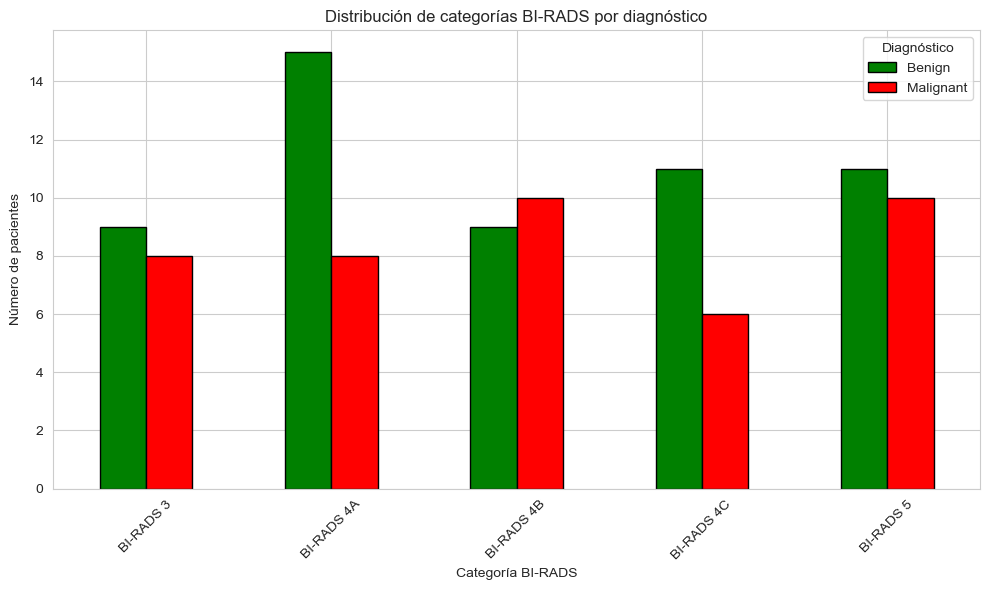


--- Tabla de contingencia ---
diagnostic         Benign  Malignant
Categoría BI-RADS                   
BI-RADS 3               9          8
BI-RADS 4A             15          8
BI-RADS 4B              9         10
BI-RADS 4C             11          6
BI-RADS 5              11         10


In [4]:
# Cargar datos
query2 = '''
SELECT r.diagnostic, r."Categoría BI-RADS"
FROM RADIOLOGIA r
WHERE r.diagnostic IS NOT NULL 
  AND r."Categoría BI-RADS" IS NOT NULL
'''

df_birads = pd.read_sql_query(query2, conn)

# Crear gráfico de barras agrupadas
cross_tab = pd.crosstab(df_birads['Categoría BI-RADS'], df_birads['diagnostic'])

cross_tab.plot(kind='bar', color=['green', 'red'], edgecolor='black')
plt.title('Distribución de categorías BI-RADS por diagnóstico')
plt.xlabel('Categoría BI-RADS')
plt.ylabel('Número de pacientes')
plt.xticks(rotation=45)
plt.legend(title='Diagnóstico')
plt.tight_layout()
plt.show()

print("\n--- Tabla de contingencia ---")
print(cross_tab)

Gráfico 3: Top 10 variantes genéticas más frecuentes en Malignant

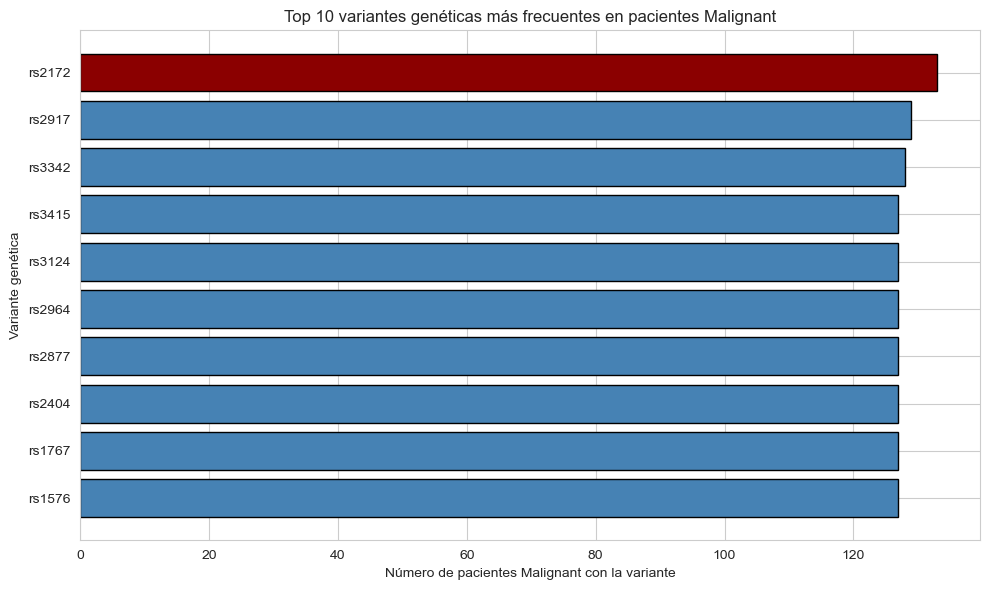


--- Top 10 variantes en Malignant ---
  variant_id  frecuencia_total  en_malignos
0     rs2172               306          133
1     rs2917               296          129
2     rs3342               303          128
3     rs3415               309          127
4     rs3124               302          127
5     rs2964               309          127
6     rs2877               312          127
7     rs2404               303          127
8     rs1767               322          127
9     rs1576               317          127


In [5]:
# Cargar datos
query3 = '''
SELECT 
    g.variant_id,
    COUNT(*) as frecuencia_total,
    SUM(CASE WHEN r.diagnostic = 'Malignant' THEN 1 ELSE 0 END) as en_malignos
FROM GENOMICA g
JOIN RADIOLOGIA r ON g.patient_id = r.patient_id
WHERE g.genotype IN ('0/1', '1/0', '1/1')
  AND r.diagnostic IS NOT NULL
GROUP BY g.variant_id
ORDER BY en_malignos DESC
LIMIT 10
'''

df_variantes = pd.read_sql_query(query3, conn)

# Crear gráfico de barras
colors = ['darkred' if x == df_variantes['en_malignos'].max() else 'steelblue' 
          for x in df_variantes['en_malignos']]

plt.barh(df_variantes['variant_id'], df_variantes['en_malignos'], color=colors, edgecolor='black')
plt.xlabel('Número de pacientes Malignant con la variante')
plt.ylabel('Variante genética')
plt.title('Top 10 variantes genéticas más frecuentes en pacientes Malignant')
plt.gca().invert_yaxis()  # Para que el más frecuente quede arriba
plt.tight_layout()
plt.show()

print("\n--- Top 10 variantes en Malignant ---")
print(df_variantes)

Conclusiones clínicas (para tu presentación)

In [6]:
# Generar conclusiones automáticas
print("\n" + "="*50)
print("📋 CONCLUSIONES CLÍNICAS DEL ESTUDIO")
print("="*50)

# Calcular algunas métricas clave
diagnostico_counts = df_tumor['diagnostic'].value_counts()
total_pacientes = len(df_tumor)

# Conclusión 1
print(f"\n1. Composición de la cohorte:")
print(f"   - {diagnostico_counts.get('Malignant', 0)} pacientes Malignant ({diagnostico_counts.get('Malignant', 0)/total_pacientes*100:.1f}%)")
print(f"   - {diagnostico_counts.get('Benign', 0)} pacientes Benign ({diagnostico_counts.get('Benign', 0)/total_pacientes*100:.1f}%)")

# Conclusión 2
radius_maligno = df_tumor[df_tumor['diagnostic']=='Malignant']['radius'].mean()
radius_benigno = df_tumor[df_tumor['diagnostic']=='Benign']['radius'].mean()
print(f"\n2. Los tumores Malignant tienen un radio promedio {radius_maligno:.1f}mm,")
print(f"   mientras que los Benign miden {radius_benigno:.1f}mm de promedio.")
print(f"   → Diferencia de {radius_maligno - radius_benigno:.1f}mm.")

# Conclusión 3
birads_maligno = df_birads[df_birads['diagnostic']=='Malignant']['Categoría BI-RADS'].value_counts()
if not birads_maligno.empty:
    top_birads = birads_maligno.index[0]
    print(f"\n3. La categoría BI-RADS más frecuente en Malignant es {top_birads}.")
    print(f"   → Esto sugiere que a mayor categoría BI-RADS, mayor probabilidad de malignidad.")

print("\n" + "="*50)
print("✅ Análisis completado. Los gráficos y conclusiones están listos para la presentación.")
print("="*50)


📋 CONCLUSIONES CLÍNICAS DEL ESTUDIO

1. Composición de la cohorte:
   - 214 pacientes Malignant (37.3%)
   - 359 pacientes Benign (62.7%)

2. Los tumores Malignant tienen un radio promedio 18.1mm,
   mientras que los Benign miden 12.2mm de promedio.
   → Diferencia de 5.9mm.

3. La categoría BI-RADS más frecuente en Malignant es BI-RADS 4B.
   → Esto sugiere que a mayor categoría BI-RADS, mayor probabilidad de malignidad.

✅ Análisis completado. Los gráficos y conclusiones están listos para la presentación.


In [7]:
conn.close()
print("\n🏁 Notebook 3 finalizado. Base de datos cerrada.")


🏁 Notebook 3 finalizado. Base de datos cerrada.
